## DEMO 2.2: **Decision Trees**
<u>Nội dung</u>:
1. Phân lớp IRIS
2. Phân lớp Social_Network_Ads  

<u>Cập nhật</u>: **04/2026**




---
### **MÔI TRƯỜNG TRIỂN KHAI ỨNG DỤNG**
---

In [1]:
## Kết nối Google Drive
from google.colab import drive
drive.mount("/content/gdrive", force_remount = True)

folder = '/content/gdrive/My Drive/Edu/1. UEH/Machine Learning/1. Demo/Ch2 - Supervised Learning'

Mounted at /content/gdrive


In [4]:
## Thư viện xử lý DL
import numpy                    as np
import pandas                   as pd

## Xây dựng mô hình
import joblib                   as jlb
from   sklearn                  import tree
from   sklearn.model_selection  import train_test_split
from   sklearn.tree             import DecisionTreeClassifier

## Biểu diễn trực quan DL
import imageio
from   IPython.display          import Image
import matplotlib.pyplot        as plt
import pydotplus                as pdp
import seaborn                  as sbn

## Thư viện khác
import warnings
warnings.filterwarnings('ignore')

---
#### 1. **Phân lớp IRIS**
---

In [6]:
## Tập tin dữ liệu IRIS
data = pd.read_excel(folder + '/Data/Iris.xls')
print('** Metadata:')
print(data.info())

print('\n** Dữ liệu mẫu:')
print(data.head())

print('\n** Thống kê:')
print(data.describe())

** Metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   species      150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

** Dữ liệu mẫu:
   sepallength  sepalwidth  petallength  petalwidth      species
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa

** Thống kê:
       sepallength  sepalwidth  petallength  petalwidth
count   150.000000  150.000000   150.000000  150.000000

In [7]:
## Các features: [sepallength, sepalwidth, petallength, petalwidth]
X = data.drop('species', axis = 1)

## Biến target: [species]
y = data.species

print(pd.concat([X, y], axis = 1).head())

   sepallength  sepalwidth  petallength  petalwidth      species
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa


In [16]:
## Chia tập dữ liệu thành training, test sets theo tỷ lệ 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = 1)

In [17]:
##------------------------------------------------------------------------------
## Xây dựng mô hình Decision Tree
##------------------------------------------------------------------------------
clf   = DecisionTreeClassifier()
model = clf.fit(X, y) # huấn luyện để tạo  mô hình

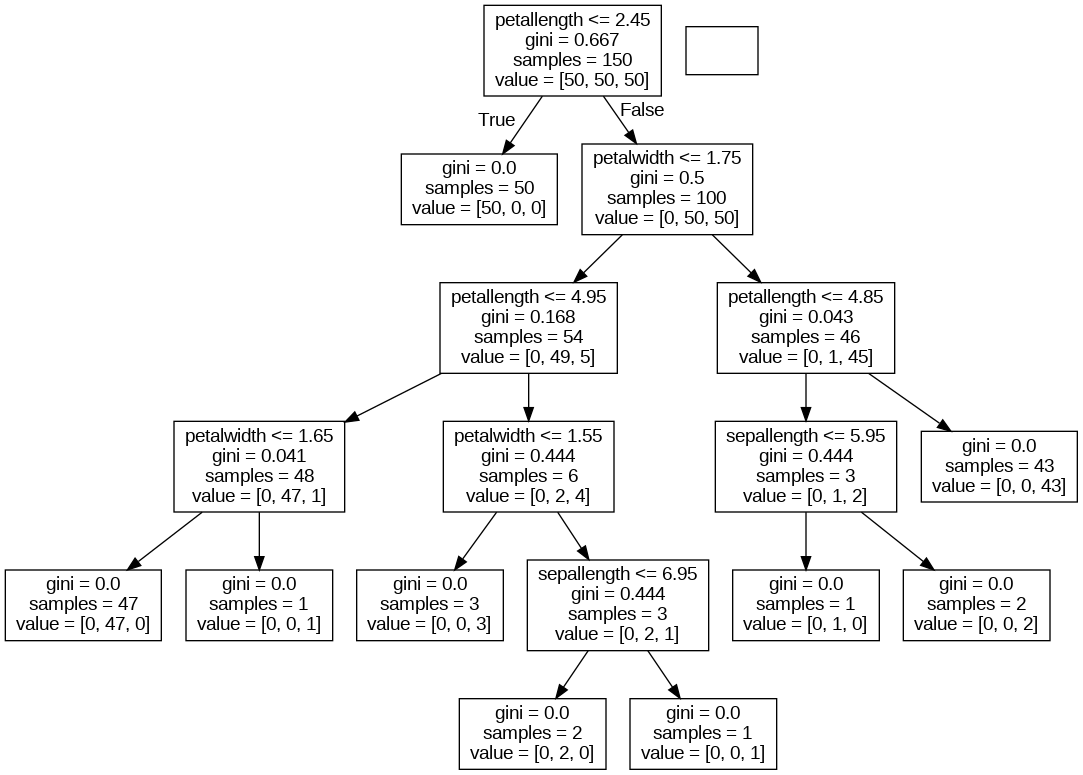

In [18]:
## Biểu diễn cây quyết định
dcs_tree = tree.export_graphviz(clf, out_file = None, feature_names = X.columns)
graph    = pdp.graph_from_dot_data(dcs_tree)
Image(graph.create_png())

In [19]:
## Lưu trữ cây quyết định vào file
graph.write_pdf(folder + "/Output/DecisionTree_Iris.pdf")
graph.write_png(folder + "/Output/DecisionTree_Iris.png")
with open(folder + "/Output/DecisionTree_Iris.txt", "w") as f:
    f = tree.export_graphviz(clf, out_file = f, feature_names = X.columns,
                                                class_names   = data.species)
    print("Đã xuất file .TXT")

Đã xuất file .TXT


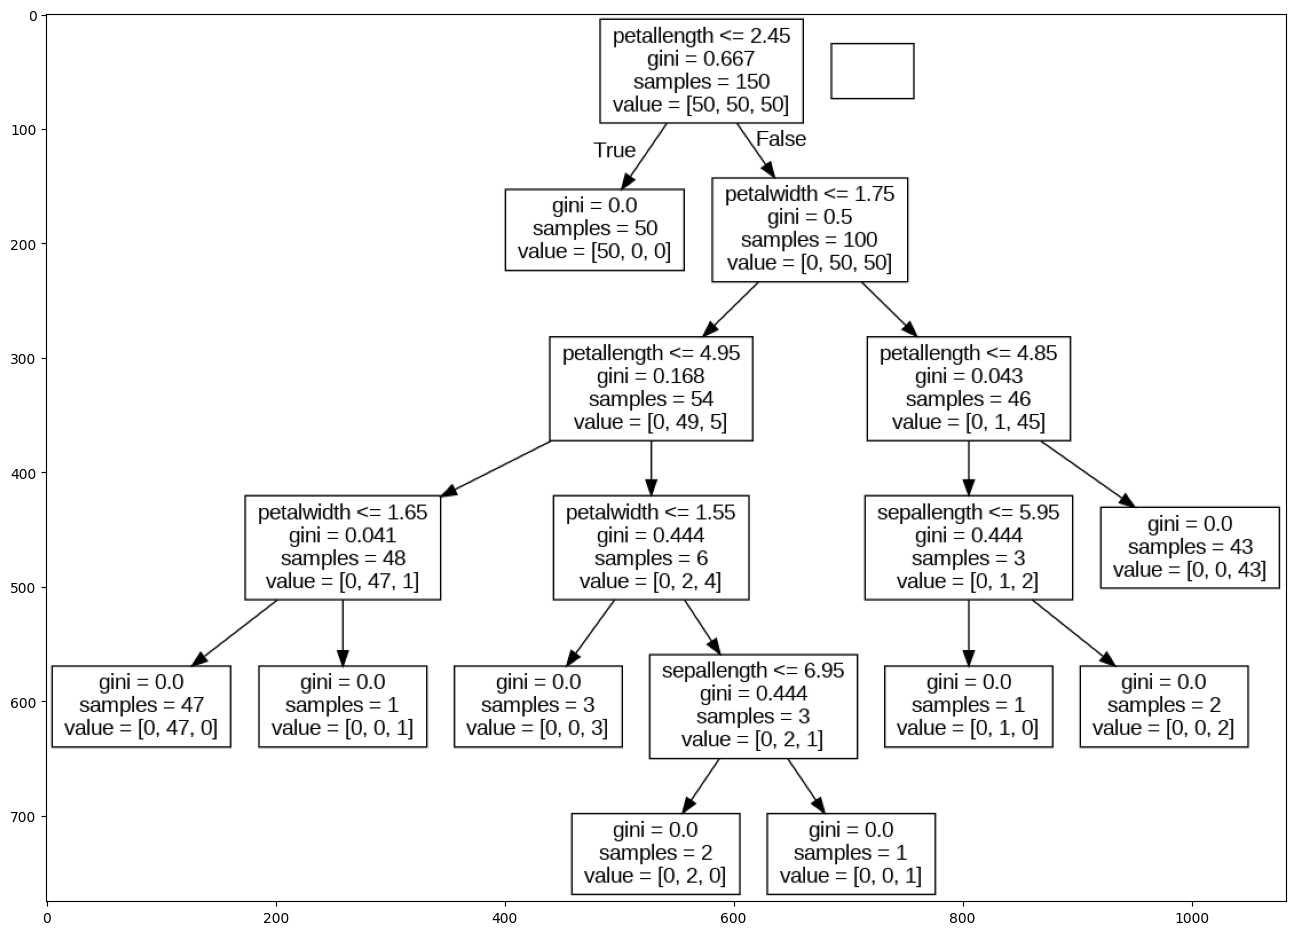

In [20]:
## Xem lại cây quyết định
photo = imageio.imread(folder + "/Output/DecisionTree_Iris.png")
plt.figure(figsize = (16, 16))
plt.imshow(photo)
plt.show()

In [21]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(model, folder + '/Output/DecisionTree_Iris.mdl')

['/content/gdrive/My Drive/Edu/1. UEH/Machine Learning/1. Demo/Ch2 - Supervised Learning/Output/DecisionTree_Iris.mdl']

In [22]:
## Khai thác mô hình đã được huấn luyện để dự đoán
model  = jlb.load(folder + '/Output/DecisionTree_Iris.mdl')

tiep = 'C'
while (tiep.upper() == 'C'):
    # Nhập dữ liệu
    spl    = float(eval(input(f'sepallength [4.3, 7.9]: ')))
    spw    = float(eval(input(f'sepalwidth  [2.0, 4.4]: ')))
    ptl    = float(eval(input(f'petallength [1.0, 6.9]: ')))
    ptw    = float(eval(input(f'petalwidth  [0.1, 2.5]: ')))
    X_new  = pd.DataFrame([spl, spw, ptl, ptw]).T

    # Dự đoán
    y_pred = model.predict(X_new)
    ## print(f'Mẫu [{X_new.to_string(index = False, header = False)}] được dự đoán là {y_pred}')
    print(f'\nMẫu {X_new.values[0].tolist()} được dự đoán là {y_pred}\n')

    tiep = input('Tiếp tục (C/K) ? ')

sepallength [4.3, 7.9]: 4.8
sepalwidth  [2.0, 4.4]: 3.4
petallength [1.0, 6.9]: 1.6
petalwidth  [0.1, 2.5]: 0.2

Mẫu [4.8, 3.4, 1.6, 0.2] được dự đoán là ['Iris-setosa']

Tiếp tục (C/K) ? K


In [23]:
## Số trường hợp đoán ĐÚNG trong tập Test
df = pd.DataFrame({'yHat':model.predict(X_test), 'y': pd.Series(y_test)})
print(f'Accuracy(Test) = {len(df[df.yHat == df.y])} / {len(X_test)}')

Accuracy(Test) = 45 / 45


---
#### 2. **Phân lớp Social_Network_Ads**
---

In [25]:
## Tập tin dữ liệu Social_Network_Ads
data = pd.read_csv(folder + '/Data/Social_Network_Ads.csv')
print(data.head().to_string(index = False))

 User ID Gender  Age  EstimatedSalary  EstimatedSalary_K  Purchased
15624510   Male   19            19000                 19          0
15810944   Male   35            20000                 20          0
15668575 Female   26            43000                 43          0
15603246 Female   27            57000                 57          0
15804002   Male   19            76000                 76          0


In [26]:
## Các features: [Gender, Age, EstimatedSalary]
X = data.drop(['User ID', 'EstimatedSalary_K', 'Purchased'], axis = 1)
X.head()

## Biến target: Purchased
y = data.Purchased

print(pd.concat([X, y], axis = 1).head().to_string(index = False))

Gender  Age  EstimatedSalary  Purchased
  Male   19            19000          0
  Male   35            20000          0
Female   26            43000          0
Female   27            57000          0
  Male   19            76000          0


In [ ]:
## Xây dựng mô hình Decision Tree